In [1]:
from imports_IBM_NM import *
%load_ext autoreload
%autoreload 2

import matplotlib as mpl
mpl.rc('text', usetex = True)
mpl.rc('font', family = 'serif')
colors_blais = ['#33658A','#86BBD8']
pycolors = plt.rcParams['axes.prop_cycle'].by_key()['color']*2
colors_greg = ['#9A0EEA', '#BF77F6', '#030AA7', '#0165FC', '#39AD48', '#F97306', '#F7022A']

In [3]:
devices = ['algiers',   ##
           #'osaka',     ##
           'cairo',     ##
           'guadalupe', ##
           'lagos',     ##
           'lima',      ##
           'belem',     ##
           'auckland',  ##
           'hanoi',     ##
           #'mumbai',
           #'kolkata',
           #'brisbane',  #
           'manila'     ##
          ]

In [16]:
Ts = pk.load(open('../data/CDF_Ts.p','rb'))

# CDF

### All together

In [31]:
T1s = []
T2s = []
for device in devices:
    for q,ts in Ts[device].items():
        T1s += [ts['T1']]
        T2s += [ts['T2']]

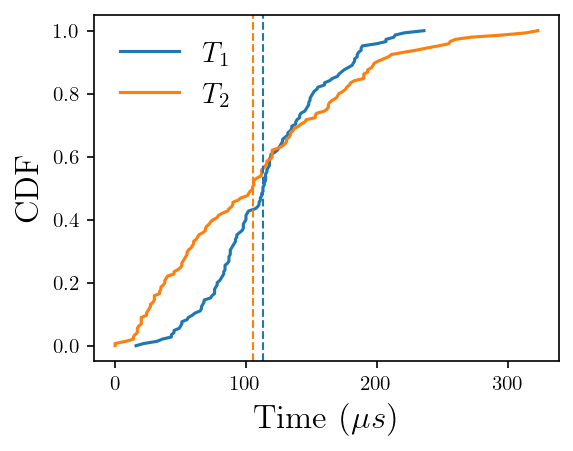

In [52]:
T1s_sorted = np.sort(T1s)
T2s_sorted = np.sort(T2s)

# calculate the proportional values of samples
p1 = 1. * np.arange(len(T1s)) / (len(T1s) - 1)
p2 = 1. * np.arange(len(T2s)) / (len(T2s) - 1)

# plot the sorted data:
plt.figure(figsize=(4,3),dpi=150)
plt.plot(T1s_sorted, p1, label='$T_1$')
plt.plot(T2s_sorted, p2, label='$T_2$')
plt.axvline(np.median(T1s), color='tab:blue', lw=1, ls='--')
plt.axvline(np.median(T2s), color='tab:orange', lw=1, ls='--')
# plt.axhline(0.5,c='k')
plt.xlabel('Time $(\mu s)$', size=16)
plt.ylabel('CDF', size=16)
plt.legend(frameon=False, fontsize=14)
plt.show()

### Each device separately

In [54]:
T1s = {device:[] for device in devices}
T2s = {device:[] for device in devices}
for device in devices:
    for q,ts in Ts[device].items():
        T1s[device] += [ts['T1']]
        T2s[device] += [ts['T2']]

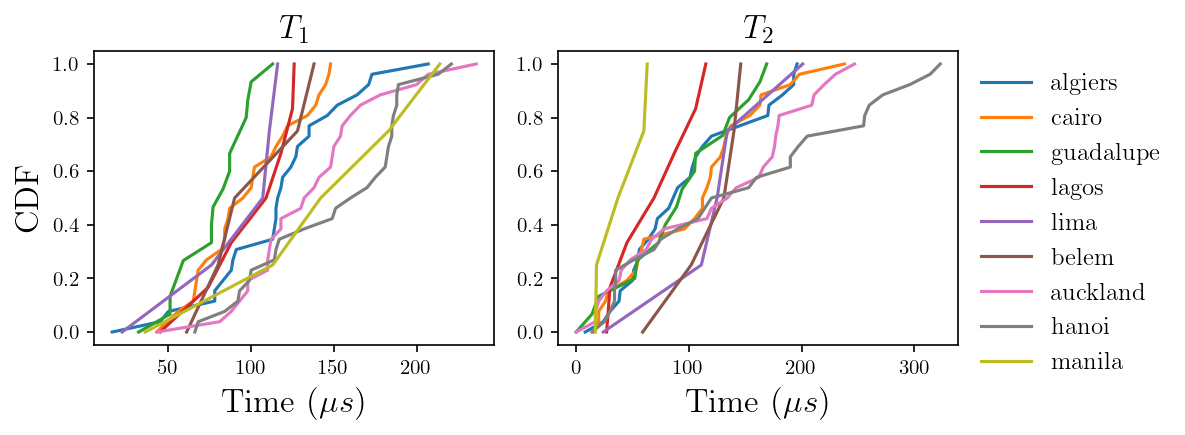

In [73]:
fig, axes = plt.subplots(1,2,figsize=(8,3),dpi=150)
for i,device in enumerate(devices):
    T1s_sorted = np.sort(T1s[device])
    T2s_sorted = np.sort(T2s[device])

    # calculate the proportional values of samples
    p1 = 1. * np.arange(len(T1s[device])) / (len(T1s[device]) - 1)
    p2 = 1. * np.arange(len(T2s[device])) / (len(T2s[device]) - 1)

    # plot the sorted data:
    axes[0].plot(T1s_sorted, p1, c=pycolors[i], ls='-')
    axes[1].plot(T2s_sorted, p2, c=pycolors[i], label=device, ls='-')
axes[0].set_title('$T_1$', size=16)
axes[1].set_title('$T_2$', size=16)
axes[0].set_xlabel('Time $(\mu s)$', size=16)
axes[1].set_xlabel('Time $(\mu s)$', size=16)
axes[0].set_ylabel('CDF', size=16)
axes[1].legend(frameon=False, fontsize=12, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

### By system size

In [18]:
sizes = [5,7,16,27]
T1s = {size:[] for size in sizes}
T2s = {size:[] for size in sizes}
for device in devices:
    for q,ts in Ts[device].items():
        size = len(Ts[device])
        T1s[size] += [ts['T1']]
        T2s[size] += [ts['T2']]

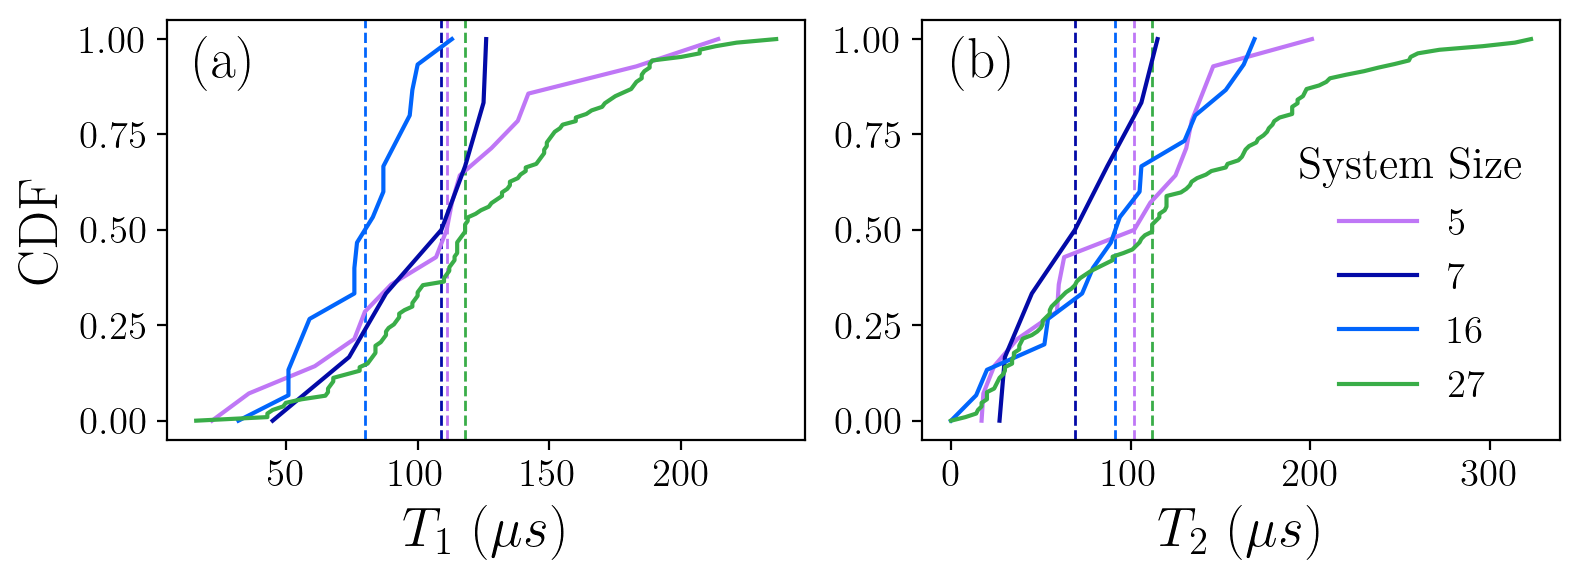

In [21]:
fig, axes = plt.subplots(1,2,figsize=(8,3),dpi=200)
for i,size in enumerate(sizes):
    T1s_sorted = np.sort(T1s[size])
    T2s_sorted = np.sort(T2s[size])

    # calculate the proportional values of samples
    p1 = 1. * np.arange(len(T1s[size])) / (len(T1s[size]) - 1)
    p2 = 1. * np.arange(len(T2s[size])) / (len(T2s[size]) - 1)

    # plot medians
    axes[0].axvline(np.median(T1s_sorted), color=colors_greg[i+1], lw=1, ls='--', zorder=-1)
    axes[1].axvline(np.median(T2s_sorted), color=colors_greg[i+1], lw=1, ls='--', zorder=-1)
    
    # plot the sorted data:
    axes[0].plot(T1s_sorted, p1, c=colors_greg[i+1], ls='-')
    axes[1].plot(T2s_sorted, p2, c=colors_greg[i+1], label=size, ls='-')
    
# axes[0].set_title('$T_1$', size=16)
# axes[1].set_title('$T_2$', size=16)
axes[0].set_xlabel('$T_1$ $(\mu s)$', size=20)
axes[1].set_xlabel('$T_2$ $(\mu s)$', size=20)
axes[0].set_ylabel('CDF', size=20)
axes[1].legend(frameon=False, fontsize=14, title='System Size', title_fontsize=16)

axes[0].text(15,.9,'(a)', size=20)
axes[1].text(0,.9,'(b)', size=20)
axes[0].tick_params(labelsize=14)
axes[1].tick_params(labelsize=14)

# axes[0].text(15,.5,'(c)', size=20)
plt.tight_layout()
# plt.savefig('figures/device_cdf.png')
plt.show()

### Small vs Large devices

In [82]:
sizes = ['Small','Large']
T1s = {size:[] for size in sizes}
T2s = {size:[] for size in sizes}
for device in devices:
    for q,ts in Ts[device].items():
        size = 'Small' if len(Ts[device])<20 else 'Large'            
        T1s[size] += [ts['T1']]
        T2s[size] += [ts['T2']]

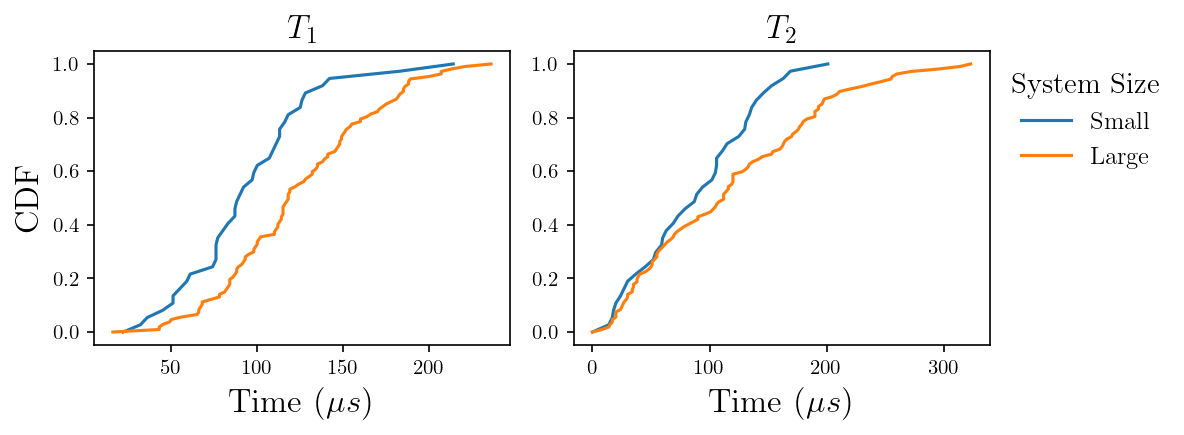

In [83]:
fig, axes = plt.subplots(1,2,figsize=(8,3),dpi=150)
for i,size in enumerate(sizes):
    T1s_sorted = np.sort(T1s[size])
    T2s_sorted = np.sort(T2s[size])

    # calculate the proportional values of samples
    p1 = 1. * np.arange(len(T1s[size])) / (len(T1s[size]) - 1)
    p2 = 1. * np.arange(len(T2s[size])) / (len(T2s[size]) - 1)

    # plot the sorted data:
    axes[0].plot(T1s_sorted, p1, c=pycolors[i], ls='-')
    axes[1].plot(T2s_sorted, p2, c=pycolors[i], label=size, ls='-')
    
#     axes[0].axvline(np.median(T1s_sorted), color=pycolors[i], lw=1, ls='--')
#     axes[1].axvline(np.median(T2s_sorted), color=pycolors[i], lw=1, ls='--')
axes[0].set_title('$T_1$', size=16)
axes[1].set_title('$T_2$', size=16)
axes[0].set_xlabel('Time $(\mu s)$', size=16)
axes[1].set_xlabel('Time $(\mu s)$', size=16)
axes[0].set_ylabel('CDF', size=16)
axes[1].legend(frameon=False, fontsize=12, bbox_to_anchor=(1,1), title='System Size', title_fontsize=14)
plt.tight_layout()
plt.show()

# Collect Times

In [4]:
Ts = {}

In [5]:
Ts['belem'] = {
    0: {'T1': 138, 'T2': 146},
    1: {'T1': 90, 'T2': 102},
    2: {'T1': 80, 'T2': 59},
    3: {'T1': 61, 'T2': 131},
    4: {'T1': 128, 'T2': 140}
}

In [6]:
Ts['manila'] = {
    0: {'T1': 36, 'T2': 18},
    1: {'T1': 214, 'T2': 63},
    2: {'T1': 142, 'T2': 17},
    3: {'T1': 183, 'T2': 60},
    4: {'T1': 113, 'T2': 37}
}

In [7]:
Ts['lima'] = {
    0: {'T1': 116, 'T2': 201},
    1: {'T1': 107, 'T2': 134},
    2: {'T1': 76, 'T2': 125},
    3: {'T1': 111, 'T2': 111},
    4: {'T1': 22, 'T2': 24}
}

In [8]:
Ts['lagos'] = {
    0: {'T1': 45, 'T2': 27},
    1: {'T1': 74, 'T2': 45},
    2: {'T1': 126, 'T2': 115},
    3: {'T1': 109, 'T2': 87},
    4: {'T1': 88, 'T2': 30},
    5: {'T1': 125, 'T2': 69},
    6: {'T1': 118, 'T2': 106}
}

In [9]:
Ts['guadalupe'] = {
    0: {'T1': 97, 'T2': 169},
    1: {'T1': 77, 'T2': 163},
    2: {'T1': 32, 'T2': 52},
    3: {'T1': 100, 'T2': 153},
    4: {'T1': 87, 'T2': 130},
    5: {'T1': 83, 'T2': 0},
    6: {'T1': 59, 'T2': 14},
    7: {'T1': 76, 'T2': 136},
    8: {'T1': 87, 'T2': 106},
    9: {'T1': 113, 'T2': 79},
    10: {'T1': 51, 'T2': 54},
    11: {'T1': 76, 'T2': 89},
    12: {'T1': 98, 'T2': 73},
    13: {'T1': 92, 'T2': 105},
    14: {'T1': 51, 'T2': 20},
    15: {'T1': 55, 'T2': 94}
}

In [10]:
Ts['auckland'] = {
    0: {'T1': 98, 'T2': 174},
    1: {'T1': 112, 'T2': 166},
    2: {'T1': 81, 'T2': 220},
    3: {'T1': 207, 'T2': 120},
    4: {'T1': 236, 'T2': 247},
    5: {'T1': 149, 'T2': 62},
    6: {'T1': 160, 'T2': 177},
    7: {'T1': 110, 'T2': 176},
    8: {'T1': 93, 'T2': 78},
    9: {'T1': 88, 'T2': 211},
    10: {'T1': 154, 'T2': 48},
    11: {'T1': 148, 'T2': 116},
    12: {'T1': 166, 'T2': 180},
    13: {'T1': 200, 'T2': 27},
    14: {'T1': 130, 'T2': 209},
    15: {'T1': 98, 'T2': 0},
    16: {'T1': 178, 'T2': 142},
    17: {'T1': 118, 'T2': 134},
    18: {'T1': 111, 'T2': 179},
    19: {'T1': 118, 'T2': 20},
    20: {'T1': 138, 'T2': 162},
    21: {'T1': 43, 'T2': 67},
    22: {'T1': 141, 'T2': 40},
    23: {'T1': 110, 'T2': 38},
    24: {'T1': 132, 'T2': 17},
    25: {'T1': 150, 'T2': 230},
    26: {'T1': 155, 'T2': 17}
}

In [11]:
Ts['cairo'] = {
    0: {'T1': 66, 'T2': 119},
    1: {'T1': 100, 'T2': 105},
    2: {'T1': 95, 'T2': 58},
    3: {'T1': 65, 'T2': 163},
    4: {'T1': 67, 'T2': 20},
    5: {'T1': 43, 'T2': 53},
    6: {'T1': 145, 'T2': 120},
    7: {'T1': 84, 'T2': 112},
    8: {'T1': 82, 'T2': 55},
    9: {'T1': 84, 'T2': 29},
    10: {'T1': 141, 'T2': 15},
    11: {'T1': 86, 'T2': 112},
    12: {'T1': 73, 'T2': 116},
    13: {'T1': 49, 'T2': 60},
    14: {'T1': 134, 'T2': 238},
    15: {'T1': 147, 'T2': 190},
    16: {'T1': 68, 'T2': 137},
    17: {'T1': 87, 'T2': 96},
    18: {'T1': 101, 'T2': 45},
    19: {'T1': 56, 'T2': 131},
    20: {'T1': 139, 'T2': 20},
    21: {'T1': 119, 'T2': 154},
    22: {'T1': 112, 'T2': 128},
    23: {'T1': 148, 'T2': 164},
    24: {'T1': 115, 'T2': 198},
    25: {'T1': 122, 'T2': 133},
    26: {'T1': 102, 'T2': 26}
}

In [12]:
Ts['algiers'] = {
    0: {'T1': 88, 'T2': 90},
    1: {'T1': 128, 'T2': 112},
    2: {'T1': 127, 'T2': 193},
    3: {'T1': 135, 'T2': 39},
    4: {'T1': 118, 'T2': 183},
    5: {'T1': 146, 'T2': 120},
    6: {'T1': 45, 'T2': 106},
    7: {'T1': 124, 'T2': 196},
    8: {'T1': 152, 'T2': 193},
    9: {'T1': 78, 'T2': 70},
    10: {'T1': 115, 'T2': 103},
    11: {'T1': 89, 'T2': 30},
    12: {'T1': 173, 'T2': 72},
    13: {'T1': 113, 'T2': 170},
    14: {'T1': 164, 'T2': 82},
    15: {'T1': 119, 'T2': 171},
    16: {'T1': 50, 'T2': 8},
    17: {'T1': 116, 'T2': 56},
    18: {'T1': 115, 'T2': 51},
    19: {'T1': 78, 'T2': 55},
    20: {'T1': 16, 'T2': 24},
    21: {'T1': 91, 'T2': 145},
    22: {'T1': 171, 'T2': 101},
    23: {'T1': 83, 'T2': 50},
    24: {'T1': 114, 'T2': 86},
    25: {'T1': 207, 'T2': 64},
    26: {'T1': 135, 'T2': 38}
}

In [13]:
Ts['hanoi'] = {
    0: {'T1': 181, 'T2': 260},
    1: {'T1': 117, 'T2': 90},
    2: {'T1': 175, 'T2': 272},
    3: {'T1': 149, 'T2': 34},
    4: {'T1': 189, 'T2': 14},
    5: {'T1': 92, 'T2': 114},
    6: {'T1': 84, 'T2': 255},
    7: {'T1': 182, 'T2': 296},
    8: {'T1': 188, 'T2': 314},
    9: {'T1': 186, 'T2': 323},
    10: {'T1': 68, 'T2': 153},
    11: {'T1': 160, 'T2': 205},
    12: {'T1': 221, 'T2': 190},
    13: {'T1': 170, 'T2': 160},
    14: {'T1': 185, 'T2': 25},
    15: {'T1': 99, 'T2': 35},
    16: {'T1': 188, 'T2': 256},
    17: {'T1': 100, 'T2': 51},
    18: {'T1': 183, 'T2': 197},
    19: {'T1': 132, 'T2': 190},
    20: {'T1': 114, 'T2': 75},
    21: {'T1': 151, 'T2': 34},
    22: {'T1': 66, 'T2': 108},
    23: {'T1': 213, 'T2': 69},
    24: {'T1': 115, 'T2': 35},
    25: {'T1': 185, 'T2': 120},
    26: {'T1': 93, 'T2': 30}
}

In [14]:
Ts['osaka'] = {
    0: {'T1': 215, 'T2': 193},
    1: {'T1': 388, 'T2': 411},
    2: {'T1': 274, 'T2': 227},
    3: {'T1': 408, 'T2': 222},
    4: {'T1': 297, 'T2': 214},
    5: {'T1': 100, 'T2': 223},
    6: {'T1': 223, 'T2': 207},
    7: {'T1': 448, 'T2': 89},
    8: {'T1': 230, 'T2': 21},
    9: {'T1': 333, 'T2': 72},
    10: {'T1': 270, 'T2': 288},
    11: {'T1': 253, 'T2': 280},
    12: {'T1': 350, 'T2': 114},
    13: {'T1': 170, 'T2': 88},
    14: {'T1': 280, 'T2': 32},
    15: {'T1': 267, 'T2': 285},
    16: {'T1': 7, 'T2': 332},
    17: {'T1': 241, 'T2': 215},
    18: {'T1': 435, 'T2': 96},
    19: {'T1': 389, 'T2': 147},
    20: {'T1': 338, 'T2': 151},
    21: {'T1': 382, 'T2': 149},
    22: {'T1': 330, 'T2': 265},
    23: {'T1': 474, 'T2': 142},
    24: {'T1': 258, 'T2': 194},
    25: {'T1': 196, 'T2': 255},
    26: {'T1': 333, 'T2': 18},
    27: {'T1': 374, 'T2': 179},
    28: {'T1': 265, 'T2': 45},
    29: {'T1': 448, 'T2': 328},
    30: {'T1': 204, 'T2': 123},
    31: {'T1': 220, 'T2': 182},
    32: {'T1': 382, 'T2': 156},
    33: {'T1': 27, 'T2': 12},
    34: {'T1': 388, 'T2': 195},
    35: {'T1': 111, 'T2': 233},
    36: {'T1': 403, 'T2': 216},
    37: {'T1': 190, 'T2': 46},
    38: {'T1': 310, 'T2': 94},
    39: {'T1': 299, 'T2': 161},
    40: {'T1': 75, 'T2': 6},
    41: {'T1': 161, 'T2': 95},
    42: {'T1': 179, 'T2': 5},
    43: {'T1': 400, 'T2': 316},
    44: {'T1': 418, 'T2': 23},
    45: {'T1': 273, 'T2': 366},
    46: {'T1': 351, 'T2': 278},
    47: {'T1': 410, 'T2': 43},
    48: {'T1': 357, 'T2': 214},
    49: {'T1': 183, 'T2': 75},
    50: {'T1': 170, 'T2': 190},
    51: {'T1': 182, 'T2': 41},
    52: {'T1': 247, 'T2': 66},
    53: {'T1': 317, 'T2': 8},
    54: {'T1': 391, 'T2': 111},
    55: {'T1': 256, 'T2': 115},
    56: {'T1': 97, 'T2': 69},
    57: {'T1': 90, 'T2': 67},
    58: {'T1': 369, 'T2': 300},
    59: {'T1': 311, 'T2': 214},
    60: {'T1': 297, 'T2': 279},
    61: {'T1': 323, 'T2': 245},
    62: {'T1': 393, 'T2': 23},
    63: {'T1': 390, 'T2': 207},
    64: {'T1': 150, 'T2': 142},
    65: {'T1': 368, 'T2': 271},
    66: {'T1': 230, 'T2': 17},
    67: {'T1': 392, 'T2': 109},
    68: {'T1': 150, 'T2': 171},
    69: {'T1': 285, 'T2': 247},
    70: {'T1': 299, 'T2': 62},
    71: {'T1': 255, 'T2': 293},
    72: {'T1': 343, 'T2': 204},
    73: {'T1': 241, 'T2': 126},
    74: {'T1': 148, 'T2': 153},
    75: {'T1': 337, 'T2': 126},
    76: {'T1': 284, 'T2': 181},
    77: {'T1': 544, 'T2': 161},
    78: {'T1': 252, 'T2': 279},
    79: {'T1': 328, 'T2': 233},
    80: {'T1': 113, 'T2': 151},
    81: {'T1': 255, 'T2': 26},
    82: {'T1': 271, 'T2': 192},
    83: {'T1': 409, 'T2': 120},
    84: {'T1': 294, 'T2': 146},
    85: {'T1': 257, 'T2': 168},
    86: {'T1': 176, 'T2': 181},
    87: {'T1': 307, 'T2': 168},
    88: {'T1': 84, 'T2': 73},
    89: {'T1': 178, 'T2': 122},
    90: {'T1': 251, 'T2': 339},
    91: {'T1': 258, 'T2': 234},
    92: {'T1': 294, 'T2': 100},
    93: {'T1': 361, 'T2': 13},
    94: {'T1': 355, 'T2': 302},
    95: {'T1': 437, 'T2': 132},
    96: {'T1': 256, 'T2': 327},
    97: {'T1': 405, 'T2': 363},
    98: {'T1': 416, 'T2': 41},
    99: {'T1': 417, 'T2': 274},
    100: {'T1': 201, 'T2': 178},
    101: {'T1': 370, 'T2': 226},
    102: {'T1': 440, 'T2': 31},
    103: {'T1': 215, 'T2': 25},
    104: {'T1': 365, 'T2': 24},
    105: {'T1': 301, 'T2': 28},
    106: {'T1': 33, 'T2': 127},
    107: {'T1': 379, 'T2': 389},
    108: {'T1': 151, 'T2': 178},
    109: {'T1': 214, 'T2': 64},
    110: {'T1': 143, 'T2': 90},
    111: {'T1': 170, 'T2': 8},
    112: {'T1': 451, 'T2': 390},
    113: {'T1': 406, 'T2': 365},
    114: {'T1': 222, 'T2': 85},
    115: {'T1': 243, 'T2': 188},
    116: {'T1': 241, 'T2': 290},
    117: {'T1': 204, 'T2': 10},
    118: {'T1': 189, 'T2': 16},
    119: {'T1': 213, 'T2': 10},
    120: {'T1': 276, 'T2': 162},
    121: {'T1': 298, 'T2': 27},
    122: {'T1': 179, 'T2': 60},
    123: {'T1': 254, 'T2': 39},
    124: {'T1': 331, 'T2': 17},
    125: {'T1': 224, 'T2': 54},
    126: {'T1': 76, 'T2': 71}
}

In [15]:
pk.dump(Ts, open('../data/CDF_Ts.p','wb'))

In [ ]:
Ts['brisbane'] = 
q = 0: T1 = 318us, T2 = 81us
q = 1: T1 = 285us, T2 = 226us
q = 2: T1 = 261us, T2 = 167us
q = 3: T1 = 111us, T2 = 122us
q = 4: T1 = 360us, T2 = 304us
q = 5: T1 = 285us, T2 = 248us
q = 6: T1 = 352us, T2 = 169us
q = 7: T1 = 342us, T2 = 330us
q = 8: T1 = 303us, T2 = 228us
q = 9: T1 = 321us, T2 = 136us
q = 10: T1 = 264us, T2 = 289us
q = 11: T1 = 206us, T2 = 274us
q = 12: T1 = 283us, T2 = 175us
q = 13: T1 = 261us, T2 = 96us
q = 14: T1 = 237us, T2 = 115us
q = 15: T1 = 240us, T2 = 52us
q = 16: T1 = 104us, T2 = 15us
q = 17: T1 = 275us, T2 = 167us
q = 18: T1 = 237us, T2 = 88us
q = 19: T1 = 261us, T2 = 93us
q = 20: T1 = 147us, T2 = 154us
q = 21: T1 = 212us, T2 = 55us
q = 22: T1 = 253us, T2 = 205us
q = 23: T1 = 383us, T2 = 115us
q = 24: T1 = 224us, T2 = 74us
q = 25: T1 = 297us, T2 = 115us
q = 26: T1 = 327us, T2 = 146us
q = 27: T1 = 285us, T2 = 223us
q = 28: T1 = 196us, T2 = 84us
q = 29: T1 = 256us, T2 = 370us
q = 30: T1 = 445us, T2 = 68us
q = 31: T1 = 341us, T2 = 58us
q = 32: T1 = 229us, T2 = 132us
q = 33: T1 = 243us, T2 = 129us
q = 34: T1 = 248us, T2 = 85us
q = 35: T1 = 284us, T2 = 123us
q = 36: T1 = 339us, T2 = 261us
q = 37: T1 = 209us, T2 = 64us
q = 38: T1 = 322us, T2 = 131us
q = 39: T1 = 323us, T2 = 117us
q = 40: T1 = 357us, T2 = 20us
q = 41: T1 = 293us, T2 = 226us
q = 42: T1 = 234us, T2 = 81us
q = 43: T1 = 118us, T2 = 270us
q = 44: T1 = 344us, T2 = 21us
q = 45: T1 = 260us, T2 = 27us
q = 46: T1 = 9us, T2 = 262us
q = 47: T1 = 186us, T2 = 168us
q = 48: T1 = 190us, T2 = 92us
q = 49: T1 = 299us, T2 = 46us
q = 50: T1 = 245us, T2 = 46us
q = 51: T1 = 252us, T2 = 311us
q = 52: T1 = 154us, T2 = 182us
q = 53: T1 = 262us, T2 = 228us
q = 54: T1 = 271us, T2 = 149us
q = 55: T1 = 297us, T2 = 105us
q = 56: T1 = 249us, T2 = 141us
q = 57: T1 = 222us, T2 = 158us
q = 58: T1 = 281us, T2 = 86us
q = 59: T1 = 284us, T2 = 55us
q = 60: T1 = 241us, T2 = 92us
q = 61: T1 = 205us, T2 = 156us
q = 62: T1 = 230us, T2 = 152us
q = 63: T1 = 261us, T2 = 242us
q = 64: T1 = 256us, T2 = 171us
q = 65: T1 = 303us, T2 = 130us
q = 66: T1 = 217us, T2 = 178us
q = 67: T1 = 348us, T2 = 176us
q = 68: T1 = 177us, T2 = 34us
q = 69: T1 = 206us, T2 = 137us
q = 70: T1 = 217us, T2 = 158us
q = 71: T1 = 279us, T2 = 287us
q = 72: T1 = 129us, T2 = 76us
q = 73: T1 = 264us, T2 = 243us
q = 74: T1 = 208us, T2 = 109us
q = 75: T1 = 44us, T2 = 59us
q = 76: T1 = 164us, T2 = 80us
q = 77: T1 = 241us, T2 = 99us
q = 78: T1 = 185us, T2 = 151us
q = 79: T1 = 294us, T2 = 66us
q = 80: T1 = 174us, T2 = 224us
q = 81: T1 = 215us, T2 = 327us
q = 82: T1 = 223us, T2 = 292us
q = 83: T1 = 234us, T2 = 72us
q = 84: T1 = 125us, T2 = 116us
q = 85: T1 = 85us, T2 = 186us
q = 86: T1 = 128us, T2 = 129us
q = 87: T1 = 259us, T2 = 202us
q = 88: T1 = 234us, T2 = 96us
q = 89: T1 = 180us, T2 = 100us
q = 90: T1 = 208us, T2 = 62us
q = 91: T1 = 238us, T2 = 215us
q = 92: T1 = 212us, T2 = 125us
q = 93: T1 = 182us, T2 = 82us
q = 94: T1 = 214us, T2 = 180us
q = 95: T1 = 161us, T2 = 88us
q = 96: T1 = 142us, T2 = 73us
q = 97: T1 = 158us, T2 = 93us
q = 98: T1 = 234us, T2 = 34us
q = 99: T1 = 128us, T2 = 121us
q = 100: T1 = 117us, T2 = 179us
q = 101: T1 = 191us, T2 = 178us
q = 102: T1 = 265us, T2 = 210us
q = 103: T1 = 193us, T2 = 87us
q = 104: T1 = 177us, T2 = 228us
q = 105: T1 = 165us, T2 = 68us
q = 106: T1 = 192us, T2 = 131us
q = 107: T1 = 266us, T2 = 94us
q = 108: T1 = 130us, T2 = 149us
q = 109: T1 = 260us, T2 = 247us
q = 110: T1 = 269us, T2 = 212us
q = 111: T1 = 309us, T2 = 293us
q = 112: T1 = 188us, T2 = 62us
q = 113: T1 = 162us, T2 = 185us
q = 114: T1 = 271us, T2 = 95us
q = 115: T1 = 250us, T2 = 96us
q = 116: T1 = 234us, T2 = 261us
q = 117: T1 = 158us, T2 = 132us
q = 118: T1 = 114us, T2 = 183us
q = 119: T1 = 289us, T2 = 108us
q = 120: T1 = 275us, T2 = 169us
q = 121: T1 = 171us, T2 = 160us
q = 122: T1 = 266us, T2 = 219us
q = 123: T1 = 132us, T2 = 56us
q = 124: T1 = 239us, T2 = 162us
q = 125: T1 = 313us, T2 = 182us
q = 126: T1 = 303us, T2 = 185us